In [7]:
import polars as pl
import random

In [15]:
data = pl.read_csv("/data1/prostrat-ai/data/peptide_and_clinical_data_v2.csv")
data = data.filter(data['event_type'] == 'hf')

In [24]:
peptide_columns = [c for c in data.columns if 'Peptide' in c]

In [123]:
def get_peptide_zero_percentage(df, peptide):
    return (df[peptide] == 0).sum() / len(df) * 100

In [124]:
while True:
    peptide = random.choice(peptide_columns)
    count = get_peptide_zero_percentage(data, peptide)

    if count < 60:
        print(peptide, count)
        break

Peptide_99909408 5.508474576271186


In [125]:
get_peptide_zero_percentage(data, peptide)

5.508474576271186

<Axes: xlabel='Peptide_99909408', ylabel='Count'>

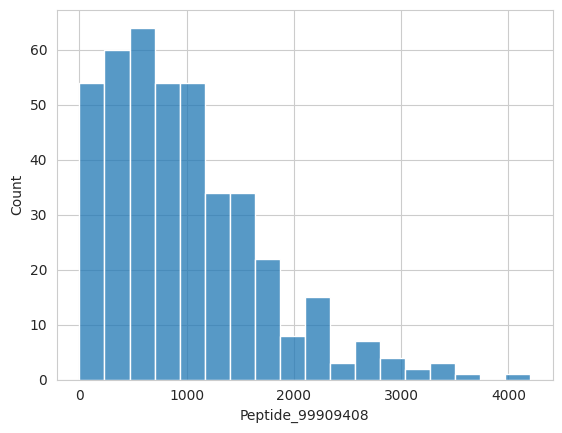

In [126]:
import seaborn as sns

sns.histplot(x=data[peptide])

In [128]:
indicator = pl.Series([1 if p != 0 else 0 for p in data[peptide]])

In [129]:
indicator.value_counts()

,count
i64,u32
1,446
0,26


In [137]:
from scipy.stats import norm
import numpy as np

In [144]:
def convert_indicator_to_numerical_column(indicator: pl.Series) -> pl.Series:
    median = indicator.mean()
    print(median)

    normal_sample = norm.rvs(loc=median, scale=1.0, size=len(indicator))

    return pl.Series(normal_sample)

In [145]:
numerical = convert_indicator_to_numerical_column(indicator)

0.9449152542372882


In [147]:
for i in range(10):
    numerical = convert_indicator_to_numerical_column(indicator)
    print(np.median(numerical))

0.9449152542372882
0.9664015410055544
0.9449152542372882
0.9746313109164545
0.9449152542372882
0.8750196254558291
0.9449152542372882
0.9895079232453957
0.9449152542372882
0.991665797639721
0.9449152542372882
0.926855422225398
0.9449152542372882
0.9866049207178775
0.9449152542372882
0.9879687516267875
0.9449152542372882
0.8349465827524962
0.9449152542372882
1.077967485997514
